# Introdução

Esse notebook tem como proposta, treinar um modelo de forecasting para previsão de fluxo de pessoas no evento Exagerado Maio de 2026, utilizando dados de vídeo monitoramento de câmeras.

# Código

In [77]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import glob
import joblib
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from itertools import product

In [74]:
import pandas as pd
import glob
import os

def carregar_relatorios():
    arquivos = sorted(glob.glob("data/relatorio_*.csv"))
    dfs = []

    for arquivo in arquivos:
        nome_arquivo = os.path.basename(arquivo)
        data_str = (
            nome_arquivo
            .replace("relatorio_", "")
            .replace(".csv", "")
        )
        data_arquivo = pd.to_datetime(
            data_str,
            format="%d-%m-%Y"
        ).strftime("%Y-%m-%d")
        df = pd.read_csv(arquivo)
        df = df.reset_index()
        df = df.drop(columns=("Área1-Pessoas que entraram"))
        df.columns = ['timestamp', 'fluxo']
        df['hora_inicio'] = df['timestamp'].str.split('-').str[0]
        df['timestamp'] = pd.to_datetime(
            data_arquivo + ' ' + df['hora_inicio']
        )
        df.set_index('timestamp', inplace=True)
        df.drop(columns=['hora_inicio'], inplace=True)
        dfs.append(df)
    df_final = pd.concat(dfs)
    df_final = df_final.sort_index()
    df_final.index.freq = 'h'

    return df_final

df = carregar_relatorios()

print(df.head())
print(df.describe())

                     fluxo
timestamp                 
2026-05-06 00:00:00      5
2026-05-06 01:00:00      0
2026-05-06 02:00:00      0
2026-05-06 03:00:00      0
2026-05-06 04:00:00      0
            fluxo
count   24.000000
mean   293.833333
std    305.530425
min      0.000000
25%      2.500000
50%    231.000000
75%    532.000000
max    968.000000


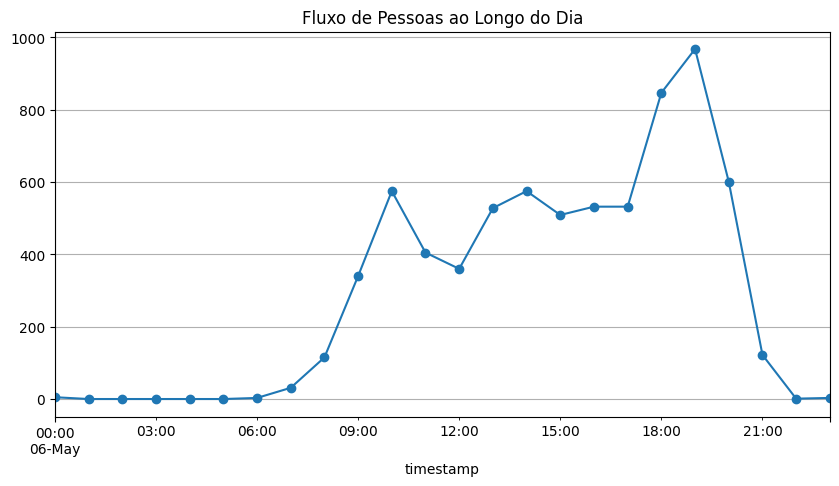

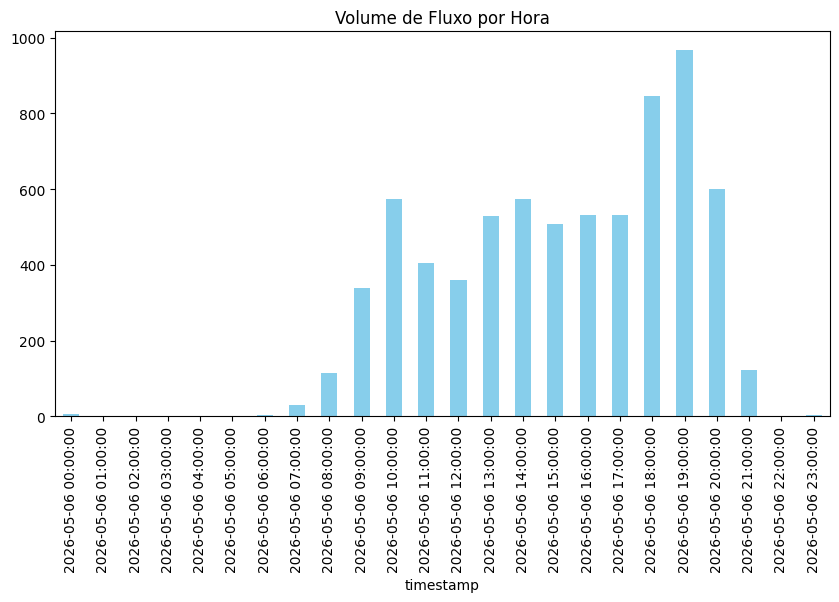

In [75]:
df['fluxo'].plot(kind='line', figsize=(10, 5), title='Fluxo de Pessoas ao Longo do Dia', marker='o')
plt.grid(True)
plt.show()

df['fluxo'].plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title('Volume de Fluxo por Hora')
plt.show()

In [86]:
# Cálculo do Threshold (Média + 2.5 desvios padrão)
stats_loja = {
    'media_historica': df['fluxo'].mean(),
    'desvio_padrao': df['fluxo'].std(),
    'threshold_alerta': df['fluxo'].mean() + (1.5 * df['fluxo'].std())
}

stats_loja

{'media_historica': np.float64(293.8333333333333),
 'desvio_padrao': np.float64(305.53042496568185),
 'threshold_alerta': np.float64(752.1289707818561)}

In [78]:
def treinar_melhor_ets(serie):
    # Parâmetros para testar
    trends = ['add', None]
    seasonal_periods = [12, 24] # Ciclos comuns de eventos
    
    best_aic = float("inf")
    best_model = None

    # Testamos as combinações
    for t, s in product(trends, seasonal_periods):
        try:
            # Com poucos dados, 'add' (aditivo) é mais estável que 'mul'
            model = ExponentialSmoothing(
                serie, 
                trend=t, 
                seasonal='add', 
                seasonal_periods=s
            ).fit()
            
            if model.aic < best_aic:
                best_aic = model.aic
                best_model = model
        except:
            continue
            
    return best_model

# Executando o treino
modelo_final = treinar_melhor_ets(df['fluxo'])
print(f"Modelo treinado! AIC: {modelo_final.aic}")

Modelo treinado! AIC: 266.62809216432004


In [ ]:
hora_atual = datetime.now().hour
proxima_hora = hora_atual + 1

passos_a_frente = proxima_hora + 1
previsoes = modelo_final.forecast(passos_a_frente)

valor_alvo = previsoes.iloc[-1]
horario_alvo = previsoes.index[-1]

print(f"Previsão para {horario_alvo}: {max(0, valor_alvo)}")


Previsão para 2026-05-07 14:00:00: 71.28190248841322


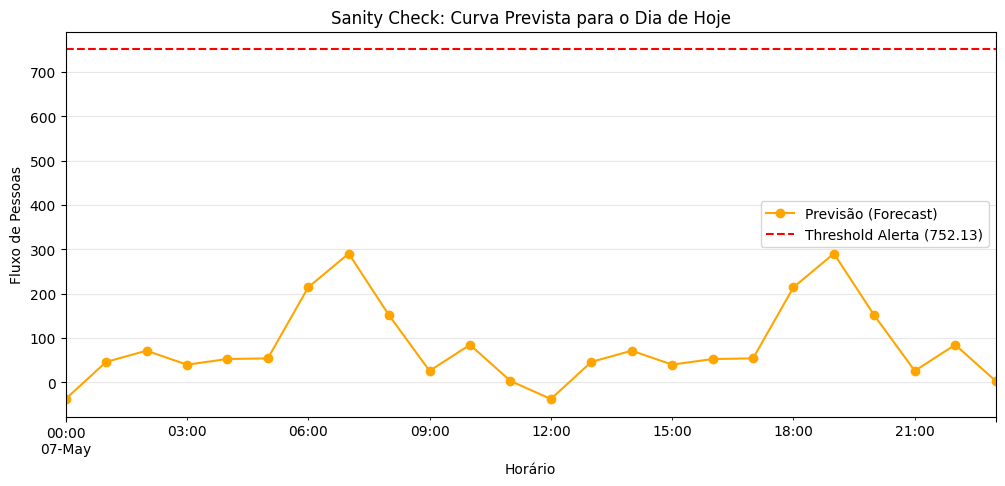

Pico previsto para hoje:
2026-05-07 07:00:00    290.50877
2026-05-07 19:00:00    290.50877
2026-05-07 18:00:00    214.43620
dtype: float64


In [88]:
previsao_hoje = modelo_final.forecast(24)

plt.figure(figsize=(12, 5))
previsao_hoje.plot(kind='line', marker='o', color='orange', label='Previsão (Forecast)')

threshold = stats_loja['threshold_alerta']
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold Alerta ({threshold:.2f})')

plt.title("Sanity Check: Curva Prevista para o Dia de Hoje")
plt.xlabel("Horário")
plt.ylabel("Fluxo de Pessoas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Pico previsto para hoje:")
print(previsao_hoje.sort_values(ascending=False).head(3))